In [1]:
import yaml
import numpy as np 
from pytorch_lightning import Trainer
import importlib
from tqdm import tqdm

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
path = 'config/attentional_cue/attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor.yaml'
config = yaml.load(open(path, 'r'), Loader=yaml.FullLoader)

In [8]:
config

{'data': {'num_words': 794,
  'multi_distractor': True,
  'corpus': {'n_talkers': [1, 5],
   'root': '/om2/user/msaddler/projects/ibmHearingAid/assets/data/datasets/JSIN_v3.00/nStim_20000/2000ms/rms_0.1/noiseSNR_-10_10/stimSR_20000/reverb_none/noise_all/JSIN_all_v3/subsets/'},
  'audio': {'rep_type': 'cochlea_filt',
   'rep_kwargs': {'sr': 20000,
    'env_sr': 8000,
    'n_channels': 40,
    'low_lim': 40,
    'use_pad': True,
    'rep_on_gpu': False,
    'env_extraction_type': 'Half-wave Rectification',
    'downsampling_type': 'TorchTransformsResample',
    'downsampling_kwargs': {'lowpass_filter_width': 64,
     'rolloff': 0.9475937167399596,
     'resampling_method': 'kaiser_window',
     'beta': 14.769656459379492}},
   'compression_type': 'coch_p3',
   'compression_kwargs': {'scale': 1,
    'offset': 1e-07,
    'clip_value': 5,
    'power': 0.3}},
  'loader': {'batch_size': 64}},
 'noise_kwargs': {'low_snr': -10, 'high_snr': 10},
 'val_metric': 'ACC/val_acc',
 'model_name': 'Mult

In [9]:
config['n_jobs'] = 10
config['data']['multi_distractor'] = False
del config['data']['corpus']['n_talkers']
config['data']['loader']['batch_size'] = 5
config['noise_kwargs']['low_snr'] = 40
config['noise_kwargs']['high_snr'] = 40

ckpt_path =  "/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_cue_jsin_multi_distractor_w_audioset_bs_64_lr_1e-4/checkpoints/epoch=0-step=70000.ckpt"

In [5]:
config

{'data': {'num_words': 794,
  'multi_distractor': False,
  'corpus': {'n_talkers': [1, 5],
   'root': '/om2/user/msaddler/projects/ibmHearingAid/assets/data/datasets/JSIN_v3.00/nStim_20000/2000ms/rms_0.1/noiseSNR_-10_10/stimSR_20000/reverb_none/noise_all/JSIN_all_v3/subsets/'},
  'audio': {'rep_type': 'cochlea_filt',
   'rep_kwargs': {'sr': 20000,
    'env_sr': 8000,
    'n_channels': 40,
    'low_lim': 40,
    'use_pad': True,
    'rep_on_gpu': False,
    'env_extraction_type': 'Half-wave Rectification',
    'downsampling_type': 'TorchTransformsResample',
    'downsampling_kwargs': {'lowpass_filter_width': 64,
     'rolloff': 0.9475937167399596,
     'resampling_method': 'kaiser_window',
     'beta': 14.769656459379492}},
   'compression_type': 'coch_p3',
   'compression_kwargs': {'scale': 1,
    'offset': 1e-07,
    'clip_value': 5,
    'power': 0.3}},
  'loader': {'batch_size': 5}},
 'noise_kwargs': {'low_snr': 40, 'high_snr': 40},
 'val_metric': 'ACC/val_acc',
 'model_name': 'Multi

In [51]:
from src import attn_tracking_lightning
importlib.reload(attn_tracking_lightning)

AttentionalaTrackingModule = attn_tracking_lightning.AttentionalTrackingModule

model = AttentionalaTrackingModule.load_from_checkpoint(checkpoint_path=ckpt_path, config=config)

ln_first


In [52]:
train_loader = model.val_dataloader()

In [53]:
import torch

In [ ]:
device = torch.device('cuda:0')

In [ ]:
!nvidia-smi

Fri Jun  9 13:08:56 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.106.00   Driver Version: 460.106.00   CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  GeForce GTX 108...  On   | 00000000:02:00.0 Off |                  N/A |
| 25%   38C    P8     9W / 250W |   9917MiB / 11178MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [54]:
model = model.eval().cuda()
outputs = []
labels = []
with torch.no_grad():
    for ix, batch in tqdm(enumerate(train_loader), total=200):
        mixture, cue, label = batch
        batch_out = model(cue.cuda(), mixture.cuda())
        outputs.append(batch_out)
        labels.append(label)
        if ix == 200:
            break

100%|██████████| 200/200 [00:46<00:00,  4.35it/s]


In [55]:
outputs = torch.cat(outputs, dim=0).cpu()
softmax_outputs = torch.softmax(outputs, dim=1)
labels = torch.cat(labels, dim=0).cpu()

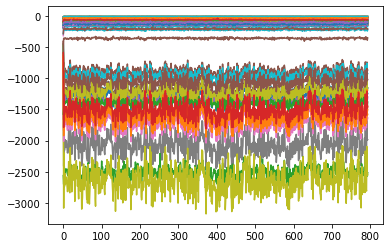

In [197]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.plot(outputs.detach().numpy().T);

In [56]:
model_guesses = softmax_outputs.argmax(-1)
model_guesses

tensor([577, 714, 715,  ..., 513, 402,  21])

In [199]:
label_array = torch.zeros_like(outputs).scatter_(1, labels.unsqueeze(-1), 1)

In [200]:
# confidence judgment 1
conf1 = softmax_outputs.max(axis=1)[0] - softmax_outputs.mean(axis=1)

In [201]:
uniform_dist = np.ones(outputs.shape) / outputs.shape[-1]
uniary_dist = np.zeros(outputs.shape[1])
uniary_dist[0] = 1
uniform_row = np.ones(uniary_dist.shape) / uniary_dist.shape[-1]

In [203]:
# confidence judgment 2
kl_loss1 = torch.nn.KLDivLoss(reduction='none', log_target=False)(torch.log(torch.Tensor(softmax_outputs)), torch.Tensor(uniform_dist)).sum(axis=1)
kl_loss2 = torch.nn.KLDivLoss(reduction='none', log_target=False)(torch.log(torch.Tensor(uniform_dist)), torch.Tensor(softmax_outputs)).sum(axis=1)
balanced_KL = (kl_loss1 + kl_loss2) / 2
entropy = torch.distributions.Categorical(probs=torch.Tensor(uniform_dist)).entropy()
conf2 = entropy + balanced_KL

min_conf2 = torch.nn.KLDivLoss(reduction='none')(torch.log(torch.Tensor(uniform_row)), torch.Tensor(uniform_row)).sum(axis=0)
min_conf2 += torch.nn.KLDivLoss(reduction='none')(torch.log(torch.Tensor(uniform_row)), torch.Tensor(uniform_row)).sum(axis=0)
min_conf2 = min_conf2 / 2
min_conf2 += torch.distributions.Categorical(probs=torch.Tensor(uniform_row)).entropy()

max_conf2 = torch.nn.KLDivLoss(reduction='none')(torch.log(torch.Tensor(uniform_row)), torch.Tensor(uniary_dist)).sum(axis=0)
max_conf2 += torch.nn.KLDivLoss(reduction='none')(torch.log(torch.Tensor(uniary_dist)), torch.Tensor(uniform_row)).sum(axis=0)
max_conf2 = max_conf2 / 2
max_conf2 += torch.distributions.Categorical(probs=torch.Tensor(uniform_row)).entropy()

In [204]:
def cross_entropy(p, q, axis=1):
    """Hand compute the cross entropy loss, where labels and outputs are arrays of the same shape
    and softmax has already been applied to p."""
    kl_loss = torch.nn.KLDivLoss(reduction='none', log_target=False)(torch.log(p), q).sum(axis = axis)
    entropy = torch.distributions.Categorical(probs=q).entropy()
    return entropy + kl_loss

In [205]:
# confidence judgment 3
conf_3 = cross_entropy(torch.Tensor(softmax_outputs), torch.Tensor(uniform_dist), 1)

min_conf3 = cross_entropy(torch.Tensor(uniform_row), torch.Tensor(uniform_row), 0)

max_conf3 = cross_entropy(torch.Tensor(uniary_dist), torch.Tensor(uniform_row), 0)

In [206]:
correct = model_guesses.numpy() == labels.numpy()
correct.mean()

0.8686567164179104

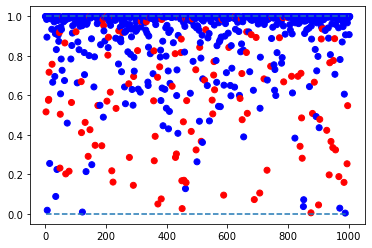

In [207]:
# confidence histograms

colors = ['b' if c else 'r' for c in correct]
plt.scatter(np.arange(len(conf1)), conf1, c=colors)
plt.hlines(0, 1, 1000, linestyles='dashed')
plt.hlines(1, 1, 1000, linestyles='dashed')


/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/matplotlib/axes/_base.py:2475: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)


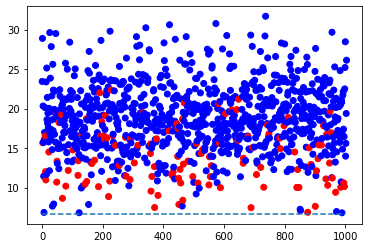

In [208]:
plt.scatter(np.arange(len(conf2)), conf2, c=colors)
plt.hlines(min_conf2, 1, 1000, linestyles='dashed')
plt.hlines(max_conf2, 1, 1000, linestyles='dashed')

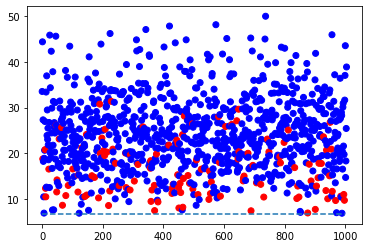

In [209]:
plt.scatter(np.arange(len(conf_3)), conf_3, c=colors)
plt.hlines(min_conf3, 1, 1000, linestyles='dashed')
plt.hlines(max_conf3, 1, 1000, linestyles='dashed')

(0.0, 1.0)

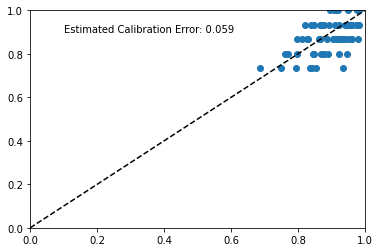

In [59]:
# plotting the softmax outputs
binned_out = softmax_outputs.view(-1, 15, 794)
batch_accuracy = (binned_out.argmax(-1) == labels.view(-1, 15)).float().mean(-1)
batch_confidence = binned_out.max(-1)[0].mean(-1)
estimated_calibration_error = (batch_confidence - batch_accuracy).abs().mean()
plt.scatter(batch_confidence, batch_accuracy)
plt.plot([0, 1], [0, 1], linestyle='dashed', color='k')
plt.annotate(f'Estimated Calibration Error: {estimated_calibration_error:.3f}', (0.1, 0.9))
plt.ylim(0, 1)
plt.xlim(0, 1)

In [25]:
class TemperatureScalingCalibrationModule(torch.nn.Module):

    def __init__(self, model_path, config):
        super().__init__()
        self.model_path = model_path
        self.model = AttentionalaTrackingModule.load_from_checkpoint(checkpoint_path=model_path, config=config)
        self.temperature = torch.nn.Parameter(torch.ones(1))

    def forward(self, cue, mixture=None):
        outputs = self.forward_logits(cue, mixture)
        scores = torch.nn.functional.softmax(outputs, dim=-1)
        return scores

    def forward_logits(self, cue, mixture=None):
        logits = self.model(cue, mixture)
        return logits / self.temperature

    def fit(self, train_loader, n_epochs=100, lr=1e-3):
        self.freeze_base_model()
        criterion = torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.SGD(self.parameters(), lr=lr)

        global_loss = float('inf')
        n_tolerance_steps = 100
        for epoch in range(n_epochs):
            for ix, batch in enumerate(train_loader):
                mixture, cue, label = batch
                self.zero_grad()
                predict = self.forward_logits(cue.cuda(), mixture.cuda())
                loss = criterion(predict, label.cuda())
                loss.backward()
                optimizer.step()

                if abs(loss.item() - global_loss) > 1e-3 and loss.item() < global_loss:
                    global_loss = loss.item()
                    n_tolerance_steps = 100
                elif abs(loss.item() - global_loss) < 1e-3:
                    n_tolerance_steps -= 1

                if n_tolerance_steps == 0:
                    return self
                if ix % 100 == 0:
                    print(f'Epoch {epoch} step: {ix} loss: {loss.item()}')
        return self
                

    def freeze_base_model(self):
        self.model.eval()
        for para in self.model.parameters():
            para.requires_grad = False

        return self



In [16]:
calibration_module = TemperatureScalingCalibrationModule(ckpt_path, config).cuda()
calibration_module.fit(train_loader, n_epochs=5, lr=1e-1)
print('# of parameters:', sum(p.numel() for p in calibration_module.parameters() if p.requires_grad))

ln_first
Epoch 0 step: 0 loss: 0.0731530636548996
Epoch 0 step: 100 loss: 1.4407224655151367
Epoch 0 step: 200 loss: 3.941483974456787
Epoch 0 step: 300 loss: 4.3122878074646
Epoch 0 step: 400 loss: 3.632981777191162


In [4]:
learned_t = torch.load('/om2/user/rphess/Auditory-Attention/confidenceScores/pilot/parameters/temperatureparemeters.pt')

In [5]:
learned_t

Parameter containing:
tensor([1.1518], device='cuda:0', requires_grad=True)

In [60]:
calibration_module = TemperatureScalingCalibrationModule(ckpt_path, config).cuda()
calibration_module.temperature = torch.nn.Parameter(learned_t)

ln_first


In [61]:
train_loader = model.val_dataloader()

In [62]:
model = calibration_module.eval().cuda()
outputs = []
labels = []
with torch.no_grad():
    for ix, batch in tqdm(enumerate(train_loader), total=200):
        mixture, cue, label = batch
        batch_out = model(cue.cuda(), mixture.cuda())
        outputs.append(batch_out)
        labels.append(label)
        if ix == 200:
            break

100%|██████████| 200/200 [00:50<00:00,  3.96it/s]


In [63]:
outputs

[tensor([[2.9037e-24, 4.7140e-13, 4.9394e-12,  ..., 4.1446e-10, 6.5810e-13,
          5.1597e-12],
         [3.3311e-29, 1.8465e-13, 5.1268e-16,  ..., 2.3039e-14, 1.0445e-17,
          9.4658e-17],
         [9.0200e-19, 2.2899e-08, 3.2286e-05,  ..., 1.1861e-05, 9.0833e-08,
          6.8348e-06],
         [3.9522e-22, 1.9383e-12, 2.7744e-09,  ..., 1.3884e-09, 1.2921e-12,
          1.0452e-11],
         [1.5051e-13, 1.1464e-07, 2.7016e-05,  ..., 1.0001e-06, 4.8195e-09,
          9.0721e-07]], device='cuda:0'),
 tensor([[1.8266e-20, 1.2515e-08, 9.2223e-10,  ..., 4.1362e-07, 1.9213e-09,
          7.3074e-07],
         [6.4002e-05, 5.9138e-04, 2.0890e-03,  ..., 1.0842e-03, 3.5086e-04,
          1.2145e-03],
         [9.0876e-15, 2.7163e-09, 1.4536e-06,  ..., 7.4043e-07, 1.8721e-06,
          1.8076e-08],
         [2.0224e-19, 2.4196e-06, 3.0326e-07,  ..., 1.0167e-07, 4.3135e-10,
          1.0694e-07],
         [1.2476e-27, 3.1698e-10, 3.0759e-11,  ..., 7.8042e-10, 3.7789e-14,
          1.43

In [64]:
outputs = torch.cat(outputs, dim=0).cpu()
labels = torch.cat(labels, dim=0).cpu()

In [65]:
outputs

tensor([[2.9037e-24, 4.7140e-13, 4.9394e-12,  ..., 4.1446e-10, 6.5810e-13,
         5.1597e-12],
        [3.3311e-29, 1.8465e-13, 5.1268e-16,  ..., 2.3039e-14, 1.0445e-17,
         9.4658e-17],
        [9.0200e-19, 2.2899e-08, 3.2286e-05,  ..., 1.1861e-05, 9.0833e-08,
         6.8348e-06],
        ...,
        [1.9549e-17, 2.2346e-08, 3.6920e-06,  ..., 2.2006e-06, 3.2924e-07,
         2.0000e-08],
        [8.8413e-21, 1.1992e-11, 2.7633e-11,  ..., 1.3450e-10, 2.0114e-12,
         6.6562e-10],
        [4.8677e-25, 3.8943e-17, 4.2824e-15,  ..., 4.4085e-13, 1.8947e-14,
         2.5235e-15]])

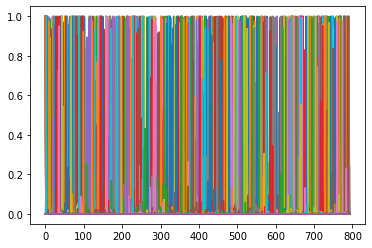

In [66]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.plot(outputs.detach().numpy().T);

In [67]:
model_guesses = outputs.argmax(-1)
model_guesses

tensor([577, 714, 715,  ..., 513, 402,  21])

(0.0, 1.0)

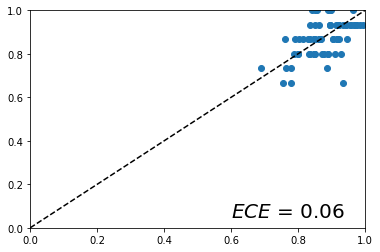

In [68]:
# plotting the softmax outputs
binned_out = outputs.view(-1, 15, 794)
batch_accuracy = (binned_out.argmax(-1) == labels.view(-1, 15)).float().mean(-1)
batch_confidence = binned_out.max(-1)[0].mean(-1)
estimated_calibration_error = (batch_confidence - batch_accuracy).abs().mean()
plt.scatter(batch_confidence, batch_accuracy)
plt.plot([0, 1], [0, 1], linestyle='dashed', color='black')
plt.annotate(f"$ECE$ = {estimated_calibration_error:.2f}", (0.6, 0.05), fontsize=20)
plt.xlim(0,1)
plt.ylim(0,1)